In [4]:
import subprocess, sys, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

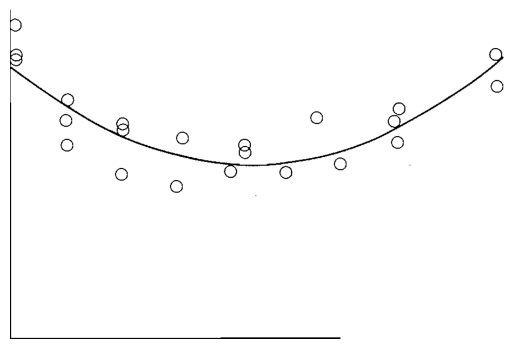

In [5]:
# This one is a doozy. Many data points, no explicit values given, but a clear linear 
# scale. Rather than manually add each point it is easier to use a Hough transform
# to identify circles.

# Extract page containing figure 1
pdf = "./data/wagner_1988.pdf"
subprocess.run(["pdfimages", "-png", pdf, "py_out/img", "-f", "2", "-l", "2"], check=True)
page = np.array(Image.open("py_out/img-000.png").convert("L"))

# Extract graph from page
origin = (277,305)
graph_size = (600,902)
graph = page[
    origin[0]:origin[0] + graph_size[0], 
    origin[1]:origin[1] + graph_size[1]
]

# remove legend
graph[
    int(graph_size[0] * 2/3):graph_size[0], 
    int(graph_size[1] * 2/3):graph_size[1]
] = 255

plt.imshow(graph, cmap='gray')
plt.axis('off')
plt.show()

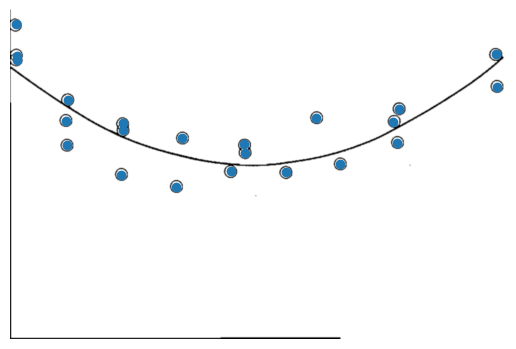

In [6]:
# Apply Hough transform to locate circles
blur = cv2.GaussianBlur(graph, (3,3), 0)
circ = cv2.HoughCircles(
    blur, 
    cv2.HOUGH_GRADIENT, 
    dp=1, 
    minDist=8,
    param1=100, 
    param2=8, 
    minRadius=9, 
    maxRadius=12
)[0]

plt.imshow(blur, cmap='gray')
plt.axis('off')
centers = np.array([(x,y) for (x,y,r) in circ])
x,y = centers.T
plt.scatter(x,y)
plt.show()

In [7]:
# Maps image coords to the actual values (in degress and m/min)
x_stretch = 45/graph_size[1]
y_stretch = 0.30/graph_size[0]
def image_to_vals(x,y):
    return (-x_stretch * x, y_stretch * (graph_size[0] - y))

vals = np.array([image_to_vals(x,y) for (x,y) in centers])

In [ ]:
# There are 3 values with |degrees| < 1. Sullivan et al. appear to have averaged
# them and used that for normalization.
R0 = np.mean([R for (theta,R) in vals if np.absolute(theta) < 1])
data = [(theta, R/R0) for (theta, R) in vals]

In [14]:
with open("py_out/wagner_1988_data.csv", "w") as f:
    f.write("theta_deg,R_normalized\n")
    for (theta,R) in data:
        f.write(f"{theta:.2f},{R:.4f}\n")
